Inertial wave dispersion relation plots from Sam.
This comes from the code 'C:\Coding\Code\Python\Useful Code\Inertial_Waves\2_point_corr.py'


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


[                                        ]0%10


TypeError: IWFilter() got an unexpected keyword argument 'phase'

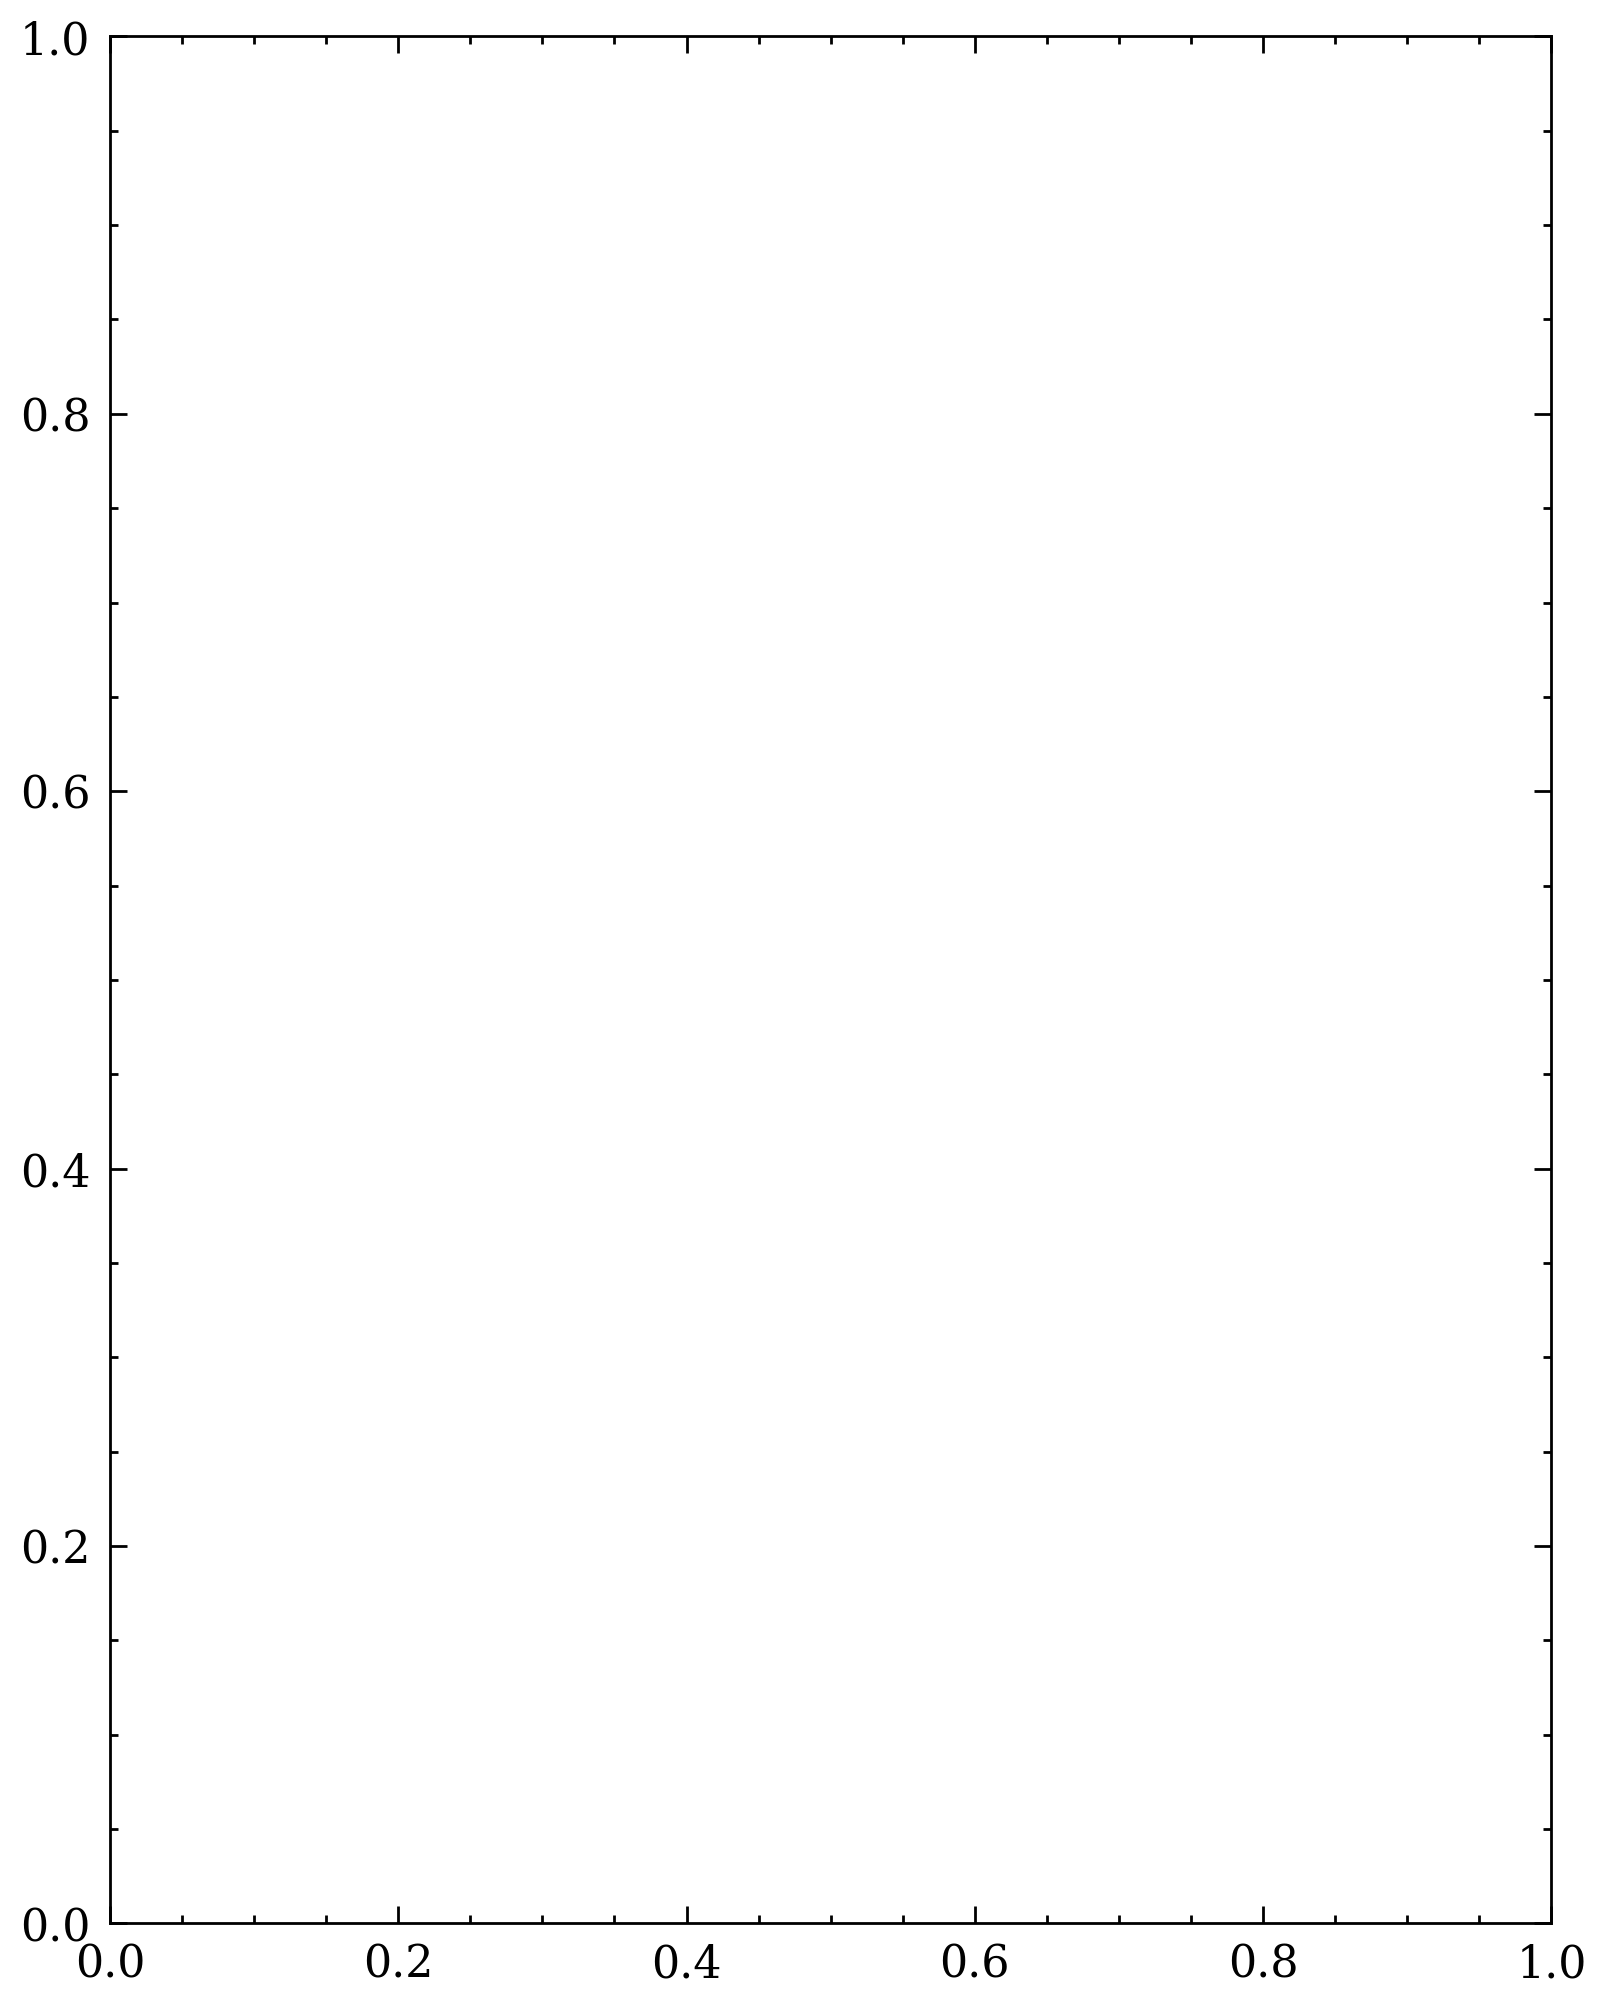

In [ ]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
Vels = ['U200']
Len = ['L100']
RPMs = ['RPM0', 'RPM3' ,'RPM6', 'RPM9', 'RPM12']

vels = h5file['Wide'][Vels[0]][Len[0]][RPMs[0]]
u = vels[:,:,:,0]
v = vels[:,:,:,1]

u = np.mean(u, axis=0)
v = np.mean(v, axis=0)

fps = np.array([60], dtype=int)
PRPM = np.array([2, 4, 8, 16, 32], dtype=int)
vel0 = 0.01162 * PRPM / 2
q0 = 0.000000329 * PRPM / 2

rpm = np.array([0, 1, 2, 3, 6, 9, 12])
RealRpm = np.array([0, 1, 2, 3, 6, 9, 12]) # 29.88,

nRot = rpm.shape[0]
nInj = PRPM.shape[0]

d = 0.006

ReArr       = np.zeros((nRot, nInj))
RoArr       = np.zeros((nRot, nInj))
EkArr       = np.zeros((nRot, nInj))

# mask = h5file['MISC']['Mask']
# ExX = mask.shape[1]
# ExY = mask.shape[0]
# proportion = ExY / ExX

f1, ax1s = plt.subplots(nrows=1, ncols=1, figsize = (4, 5))

r, z = oj.NDUnitsForPlotsWide(u.shape[0], u.shape[1])
X, Y = np.meshgrid(r, z)

Angles = np.linspace(10, 80, dtype='int')
# Angles= np.array([20, 30, 40, 50, 60, 70, 80])
# left = 31
# right = 53
left  = 71
right = 73
left  = 59###############Temp line
right = 60###############Temp line
left  = 30###############Temp line
right = 39###############Temp line

left  = int(u.shape[1]/2)###############Temp line
right = int(u.shape[1]-(u.shape[1]/2))###############Temp line


runRot = 6
runInj = 1

## Import flow field 
# data = h5file['Narrow'][Vels[0]][Len[0]]['RPM{0}'.format(rpm[runRot])]
# data = h5file['RPM{0}'.format(rpm[runRot])]['INJ{0}'.format(PRPM[runInj])]
data = h5file['Wide'][Vels[0]][Len[0]]['RPM12']

uTemp = data[:, :, : ,0] #* mask #/ vel0[runInj]
vTemp = data[:, :, : ,1] #* mask #/ vel0[runInj]
h5file.close()

uTemp = np.rot90(u, 3)###############Temp line
vTemp = v###############Temp line

vmean = np.mean(vTemp, axis=0)
vmean = np.mean(uTemp, axis=0) ###############Temp line
angMean = np.zeros(Angles.shape[0])
oj.tic()
for i in range(Angles.shape[0]):
    oj.progressBar(i, Angles.shape[0])
    ang = Angles[i]
    print(ang)

    if ang == 60:
        angMean[i] = 0 
    else:
        IWsF = oj.IWFilter(uTemp, ang, fps=60, rpm = 12)#, phase = 1)
        # IWsF = oj.IWFilter(uTemp, ang, fps=fps[runInj], rpm = RealRpm[runRot])###############Temp line
        # print(IWsF.shape)

        _,_,_,_,_,_,angDL = oj.TwoPtCorrIWs(IWsF[:, 2:, :left])
        _,_,_,_,_,_,angDR = oj.TwoPtCorrIWs(IWsF[:, 2:, right:])
        angD = (angDL+angDR)/2
        angMean[i] = angD
angMean = oj.InterpZeros(angMean)

oj.toc()

FByOmega = 2 * np.cos(np.deg2rad(Angles)) 

ax1s.plot(FByOmega, Angles, linestyle="dotted", color = 'black', label = 'Dispersion Relation')
ax1s.plot(FByOmega, angMean, color='blue', linestyle="none", marker=".", markersize=5, alpha=0.75)#, label = 'Ek - {}'.format(np.round(sb.Ek(RealRpm[runRot]), 4)))
ax1s.legend()

plt.setp(ax1s, xlabel=r'$F_{f} / F_{\Omega}$')
plt.setp(ax1s, ylabel=r"$\theta$  (deg)")

# f1.savefig('/Users/sambooth/Desktop/Thesis Bits/Ch7/VLS_2PtSingle.png', bbox_inches='tight')

plt.show()